# 1.1 - Claimback 2026 Exploratory Analysis

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 250)
pd.set_option("display.float_format", "{:,.2f}".format)

CLEAN_DATA_DIR = Path("outputs") / "cleaned_data"
SUPPORT_CLEANED_FILE = CLEAN_DATA_DIR / "support_cleaned.csv"
GL_ACCOUNTS_CLEANED_FILE = CLEAN_DATA_DIR / "gl_accounts_cleaned.csv"
GL_ENTRIES_CLEANED_FILE = CLEAN_DATA_DIR / "gl_entries_cleaned.csv"

YEAR = 2026
START_DATE = pd.Timestamp(f"{YEAR}-01-01")
SUPPORT_CUTOFF_DATE = pd.Timestamp("2026-06-01")
LEDGER_CUTOFF_DATE = pd.Timestamp("2026-07-01")
EXCLUDED_SUPPLIER_CODES = {"E005GB", "E059"}
REBATE_SUPPLIER_CODE = "U106"
REBATE_PRODUCT_CATEGORY = "PRSCU"


def read_cleaned_dataset(path):
    if not path.exists():
        raise FileNotFoundError(f"Cleaned dataset not found: {path}. Run 0.2 - Data Cleaning first.")
    return pd.read_csv(path, low_memory=False)


def supplier_group_code(code):
    code = "" if pd.isna(code) else str(code).strip()
    if code in {"L810", "L812"}:
        return "L810/L812"
    if code in {"E907", "E907GB"}:
        return "E907/E907GB"
    return code


def supplier_group_name(code, name):
    group = supplier_group_code(code)
    if group == "L810/L812":
        return "Supplier14"
    if group == "E907/E907GB":
        return "Supplier21"
    return "" if pd.isna(name) else str(name).strip()


def supplier_key(series):
    return series.astype("string").str.strip().str.upper().str.replace(" ", "", regex=False)


support = read_cleaned_dataset(SUPPORT_CLEANED_FILE)
support["Date"] = pd.to_datetime(support["claim_date"] if "claim_date" in support.columns else support["Date"], errors="coerce")
support["SupplierCode"] = support["Contract_Supplier_Code"].map(supplier_group_code)
support["SupplierName"] = [supplier_group_name(c, n) for c, n in zip(support["Contract_Supplier_Code"], support["Contract_Supplier_Name"])]
support["SupplierKey"] = supplier_key(support["SupplierName"])
support["TotalSupportOwed"] = pd.to_numeric(support["credit_due_value"], errors="coerce").fillna(0)
support["Month"] = support["Date"].dt.to_period("M").dt.to_timestamp()

support_2026 = support[
    support["Date"].ge(START_DATE)
    & support["Date"].lt(SUPPORT_CUTOFF_DATE)
    & support["SourceTransactionType"].eq("SL/Del")
    & ~support["Contract_Supplier_Code"].isin(EXCLUDED_SUPPLIER_CODES)
].copy()

accounts_raw = read_cleaned_dataset(GL_ACCOUNTS_CLEANED_FILE)
entries_raw = read_cleaned_dataset(GL_ENTRIES_CLEANED_FILE)
accounts = pd.DataFrame({
    "GLAccountCode": accounts_raw.get("gl_account_code", accounts_raw.get("Code")),
    "GLAccountDescription": accounts_raw.get("gl_account_description", accounts_raw.get("Description")),
    "SupplierKey": accounts_raw.get("gl_supplier_key", pd.Series(pd.NA, index=accounts_raw.index)),
    "CurrentBalance": pd.to_numeric(accounts_raw.get("gl_current_balance", accounts_raw.get("CurrentBalance")), errors="coerce"),
})
entries = pd.DataFrame({
    "GLAccountCode": entries_raw.get("gl_account_code", entries_raw.get("GL_Account_Code")),
    "GLAccountDescription": entries_raw.get("gl_account_description", entries_raw.get("Description")),
    "SupplierKey": entries_raw.get("gl_supplier_key", pd.Series(pd.NA, index=entries_raw.index)),
    "LedgerDate": pd.to_datetime(entries_raw.get("gl_entry_line_date", entries_raw.get("Entry_Line_Date")), errors="coerce"),
    "CreditAmount": pd.to_numeric(entries_raw.get("gl_credit_amount", entries_raw.get("Credit_Amount")), errors="coerce").fillna(0),
    "RunningBalance": pd.to_numeric(entries_raw.get("Running_Balance"), errors="coerce"),
    "TotalBalance": pd.to_numeric(entries_raw.get("Total_Balance"), errors="coerce"),
})

supplier_lookup = support_2026[["SupplierKey", "SupplierCode", "SupplierName"]].drop_duplicates("SupplierKey")
ledger = entries.merge(supplier_lookup, on="SupplierKey", how="left")
ledger = ledger[ledger["LedgerDate"].ge(START_DATE) & ledger["LedgerDate"].lt(LEDGER_CUTOFF_DATE)].copy()

names = support_2026.groupby("SupplierKey", as_index=False).agg(
    SupplierCode=("SupplierCode", "first"),
    SupplierName=("SupplierName", "first"),
    LinkedSupplierCodes=("Contract_Supplier_Code", lambda s: ", ".join(sorted(set(s.dropna().astype(str))))),
)
owed = support_2026.groupby("SupplierKey", as_index=False).agg(
    SupportLines=("Date", "size"),
    ContractCount=("Contract_D_ContractNumber", "nunique"),
    CustomerCount=("Customer", "nunique"),
    ProductCount=("Product", "nunique"),
    TotalSupportOwed=("TotalSupportOwed", "sum"),
)
paid = ledger[ledger["SupplierKey"].notna() & ledger["SupplierKey"].ne("")].groupby("SupplierKey", as_index=False).agg(
    LedgerPaid=("CreditAmount", "sum"),
    LedgerLines=("LedgerDate", "size"),
    LatestLedgerDate=("LedgerDate", "max"),
)

supplier_summary = names.merge(owed, on="SupplierKey", how="left").merge(paid, on="SupplierKey", how="left")
supplier_summary["LedgerPaid"] = supplier_summary["LedgerPaid"].fillna(0)
supplier_summary["LedgerLines"] = supplier_summary["LedgerLines"].fillna(0)
supplier_summary["Outstanding"] = supplier_summary["TotalSupportOwed"] - supplier_summary["LedgerPaid"]
supplier_summary["PaidPct"] = supplier_summary["LedgerPaid"].div(supplier_summary["TotalSupportOwed"]).where(supplier_summary["TotalSupportOwed"].ne(0), 0)
supplier_summary["SupportOwed"] = supplier_summary["TotalSupportOwed"]
supplier_summary["PaidPercent"] = supplier_summary["PaidPct"] * 100
supplier_summary = supplier_summary.sort_values("Outstanding", ascending=False)

ledger_month = ledger.groupby(ledger["LedgerDate"].dt.to_period("M").dt.to_timestamp())["CreditAmount"].sum().rename("LedgerPaid").reset_index().rename(columns={"LedgerDate": "Month"})
monthly_summary = support_2026.groupby("Month", as_index=False).agg(TotalSupportOwed=("TotalSupportOwed", "sum")).merge(ledger_month, on="Month", how="outer").fillna(0).sort_values("Month")
monthly_summary["OutstandingMovement"] = monthly_summary["TotalSupportOwed"] - monthly_summary["LedgerPaid"]

rebate_mask = support_2026["SupplierCode"].eq(REBATE_SUPPLIER_CODE) & support_2026["Product_Category"].astype("string").str.upper().eq(REBATE_PRODUCT_CATEGORY)
rebate_adjustment = pd.DataFrame([{
    "SupplierCode": REBATE_SUPPLIER_CODE,
    "SupplierName": "Supplier1",
    "ProductCategoryShownSeparately": REBATE_PRODUCT_CATEGORY,
    "SupportLines": int(rebate_mask.sum()),
    "SupportValue": float(support_2026.loc[rebate_mask, "TotalSupportOwed"].sum()),
}])

print("Support rows in report window:", support_2026.shape, "Ledger rows:", ledger.shape)
display(supplier_summary.head(10))
display(monthly_summary)
display(rebate_adjustment)


Support rows in report window: (11848, 61) Ledger rows: (89, 9)


,SupplierKey,SupplierCode,SupplierName,LinkedSupplierCodes,SupportLines,ContractCount,CustomerCount,ProductCount,TotalSupportOwed,LedgerPaid,LedgerLines,LatestLedgerDate,Outstanding,PaidPct,SupportOwed,PaidPercent
9,SUPPLIER19,E070,Supplier19,E070,410,11,12,123,"105,731.85",0.00,0.00,NaT,"105,731.85",0.00,"105,731.85",0.00
14,SUPPLIER4,U102,Supplier4,U102,173,6,57,16,"58,787.66",0.00,0.00,NaT,"58,787.66",0.00,"58,787.66",0.00
3,SUPPLIER13,E071,Supplier13,E071,617,28,102,21,"227,981.51","179,305.04",82.00,2026-03-07,"48,676.47",0.79,"227,981.51",78.65
8,SUPPLIER18,E555,Supplier18,E555,1249,33,33,116,"40,228.90",0.00,0.00,NaT,"40,228.90",0.00,"40,228.90",0.00
0,SUPPLIER1,U106,Supplier1,U106,6645,93,170,190,"35,038.99",0.00,0.00,NaT,"35,038.99",0.00,"35,038.99",0.00
11,SUPPLIER21,E907/E907GB,Supplier21,"E907, E907GB",126,7,51,24,"33,022.00","17,002.00",3.00,2026-03-08,"16,020.00",0.51,"33,022.00",51.49
4,SUPPLIER14,L810/L812,Supplier14,"L810, L812",853,0,15,139,"6,686.84",0.00,0.00,NaT,"6,686.84",0.00,"6,686.84",0.00
16,SUPPLIER7,E102,Supplier7,E102,274,2,103,14,"6,520.28",0.00,0.00,NaT,"6,520.28",0.00,"6,520.28",0.00
10,SUPPLIER20,E948,Supplier20,E948,203,11,11,83,"3,452.12",0.00,0.00,NaT,"3,452.12",0.00,"3,452.12",0.00
17,SUPPLIER8,E175,Supplier8,E175,728,3,214,10,"5,024.88","2,459.31",1.00,2026-04-06,"2,565.57",0.49,"5,024.88",48.94


,Month,TotalSupportOwed,LedgerPaid,OutstandingMovement
0,2026-01-01,"101,979.15","87,418.08","14,561.07"
1,2026-02-01,"96,834.19","3,276.00","93,558.19"
2,2026-03-01,"131,787.59","105,659.13","26,128.46"
3,2026-04-01,"89,849.76","2,776.81","87,072.95"
4,2026-05-01,"110,262.36",0.00,"110,262.36"
5,2026-06-01,0.00,339.00,-339.00


,SupplierCode,SupplierName,ProductCategoryShownSeparately,SupportLines,SupportValue
0,U106,Supplier1,PRSCU,6538,"29,412.61"


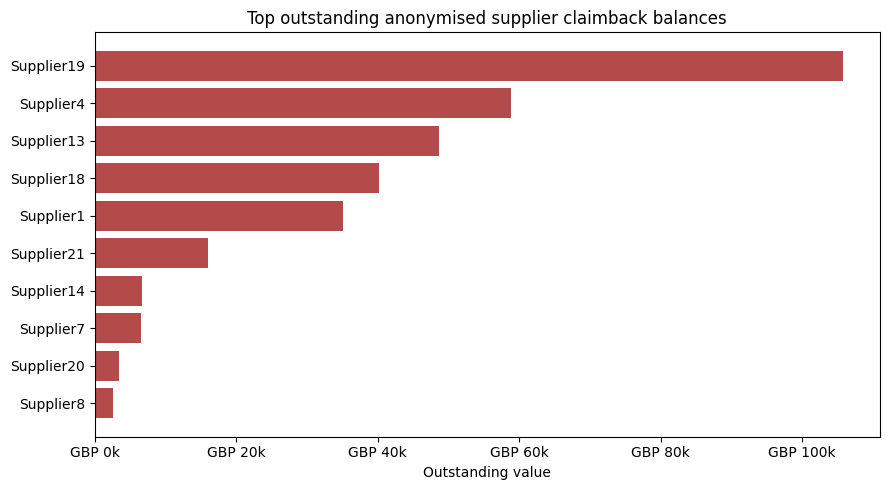

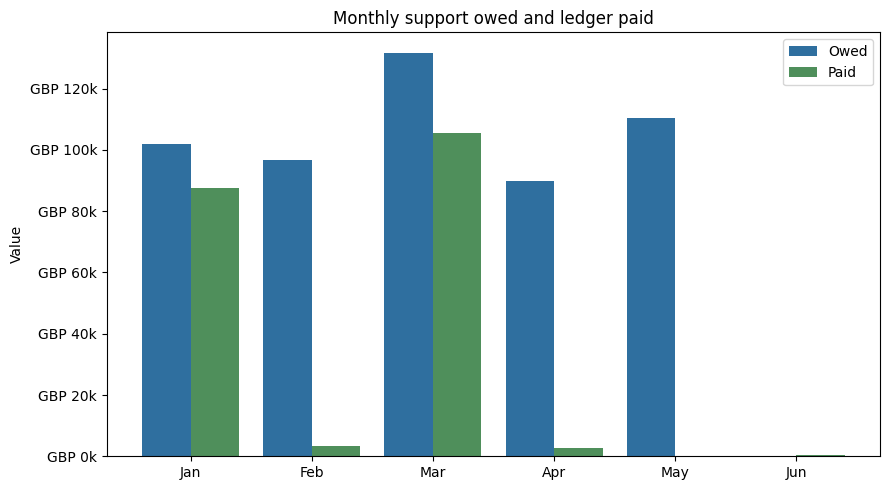

In [2]:
top=supplier_summary[supplier_summary["Outstanding"].gt(0)].head(10).sort_values("Outstanding")
fig,ax=plt.subplots(figsize=(9,5)); ax.barh(top["SupplierName"],top["Outstanding"],color="#b44a4a"); ax.set_title("Top outstanding anonymised supplier claimback balances"); ax.set_xlabel("Outstanding value"); ax.xaxis.set_major_formatter(lambda x,pos:f"GBP {x/1000:,.0f}k"); plt.tight_layout(); plt.show()
fig,ax=plt.subplots(figsize=(9,5)); x=range(len(monthly_summary)); ax.bar([i-.2 for i in x],monthly_summary["TotalSupportOwed"],width=.4,label="Owed",color="#2f6f9f"); ax.bar([i+.2 for i in x],monthly_summary["LedgerPaid"],width=.4,label="Paid",color="#4f8f5b"); ax.set_xticks(list(x),[d.strftime("%b") if hasattr(d,"strftime") else str(d) for d in monthly_summary["Month"]]); ax.set_title("Monthly support owed and ledger paid"); ax.set_ylabel("Value"); ax.legend(); ax.yaxis.set_major_formatter(lambda y,pos:f"GBP {y/1000:,.0f}k"); plt.tight_layout(); plt.show()


In [3]:
explore = supplier_summary.copy()
money_cols = [col for col in ["SupportOwed", "TrackerPaid", "LedgerPaid", "Paid", "Outstanding"] if col in explore.columns]
for col in money_cols:
    explore[col] = pd.to_numeric(explore[col], errors="coerce").fillna(0)

if "PaidPercent" not in explore.columns:
    paid_col = "LedgerPaid" if "LedgerPaid" in explore.columns else ("TrackerPaid" if "TrackerPaid" in explore.columns else "Paid")
    owed_col = "SupportOwed" if "SupportOwed" in explore.columns else "Owed"
    if paid_col in explore.columns and owed_col in explore.columns:
        explore["PaidPercent"] = np.where(explore[owed_col].gt(0), explore[paid_col] / explore[owed_col] * 100, 0)

sort_col = "Outstanding" if "Outstanding" in explore.columns else money_cols[-1]

display(explore.sort_values(sort_col, ascending=False).head(10))

,SupplierKey,SupplierCode,SupplierName,LinkedSupplierCodes,SupportLines,ContractCount,CustomerCount,ProductCount,TotalSupportOwed,LedgerPaid,LedgerLines,LatestLedgerDate,Outstanding,PaidPct,SupportOwed,PaidPercent
9,SUPPLIER19,E070,Supplier19,E070,410,11,12,123,"105,731.85",0.00,0.00,NaT,"105,731.85",0.00,"105,731.85",0.00
14,SUPPLIER4,U102,Supplier4,U102,173,6,57,16,"58,787.66",0.00,0.00,NaT,"58,787.66",0.00,"58,787.66",0.00
3,SUPPLIER13,E071,Supplier13,E071,617,28,102,21,"227,981.51","179,305.04",82.00,2026-03-07,"48,676.47",0.79,"227,981.51",78.65
8,SUPPLIER18,E555,Supplier18,E555,1249,33,33,116,"40,228.90",0.00,0.00,NaT,"40,228.90",0.00,"40,228.90",0.00
0,SUPPLIER1,U106,Supplier1,U106,6645,93,170,190,"35,038.99",0.00,0.00,NaT,"35,038.99",0.00,"35,038.99",0.00
11,SUPPLIER21,E907/E907GB,Supplier21,"E907, E907GB",126,7,51,24,"33,022.00","17,002.00",3.00,2026-03-08,"16,020.00",0.51,"33,022.00",51.49
4,SUPPLIER14,L810/L812,Supplier14,"L810, L812",853,0,15,139,"6,686.84",0.00,0.00,NaT,"6,686.84",0.00,"6,686.84",0.00
16,SUPPLIER7,E102,Supplier7,E102,274,2,103,14,"6,520.28",0.00,0.00,NaT,"6,520.28",0.00,"6,520.28",0.00
10,SUPPLIER20,E948,Supplier20,E948,203,11,11,83,"3,452.12",0.00,0.00,NaT,"3,452.12",0.00,"3,452.12",0.00
17,SUPPLIER8,E175,Supplier8,E175,728,3,214,10,"5,024.88","2,459.31",1.00,2026-04-06,"2,565.57",0.49,"5,024.88",48.94


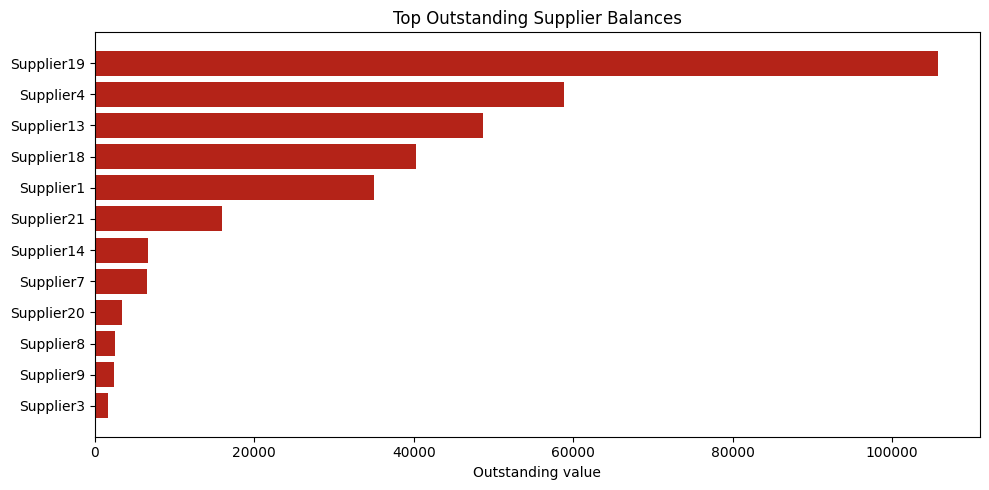

In [4]:
if "Outstanding" in explore.columns:
    top = explore[explore["Outstanding"].gt(0)].sort_values("Outstanding", ascending=False).head(12)
    plt.figure(figsize=(10, 5))
    plt.barh(top.iloc[::-1]["SupplierName"], top.iloc[::-1]["Outstanding"], color="#b42318")
    plt.title("Top Outstanding Supplier Balances")
    plt.xlabel("Outstanding value")
    plt.tight_layout()
    plt.show()

Monthly claimback movement


,Month,TotalSupportOwed,LedgerPaid,OutstandingMovement
0,2026-01-01,"101,979.15","87,418.08","14,561.07"
1,2026-02-01,"96,834.19","3,276.00","93,558.19"
2,2026-03-01,"131,787.59","105,659.13","26,128.46"
3,2026-04-01,"89,849.76","2,776.81","87,072.95"
4,2026-05-01,"110,262.36",0.00,"110,262.36"
5,2026-06-01,0.00,339.00,-339.00


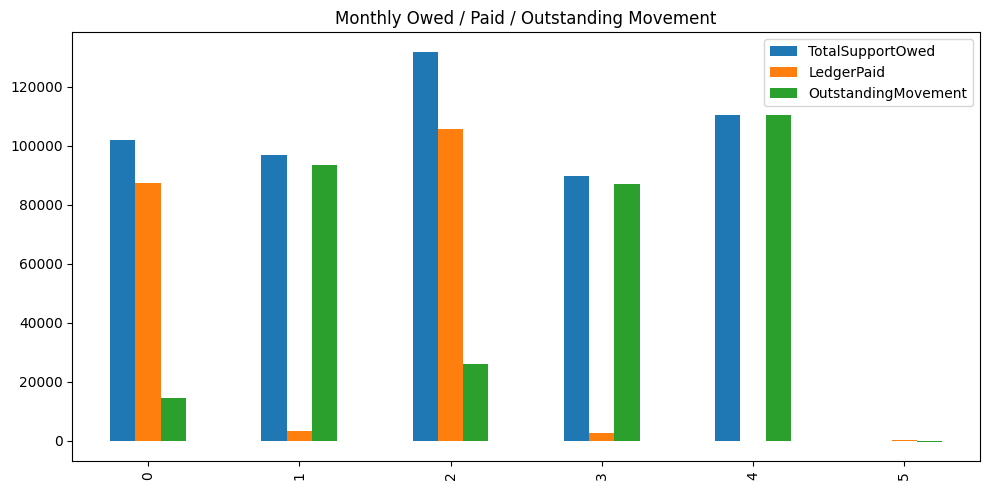

In [5]:
if "monthly_summary" in globals():
    month_view = monthly_summary.copy()
    print("Monthly claimback movement")
    display(month_view)
    numeric = month_view.select_dtypes(include=[np.number])
    if not numeric.empty:
        numeric.plot(kind="bar", figsize=(10, 5), title="Monthly Owed / Paid / Outstanding Movement")
        plt.tight_layout()
        plt.show()